# Demonstrating the Effectiveness of the Unscented Transform (UT)

## Learning Objectives
- Understand the limitations of linearizing a non-linear function for mean/covariance transformation (Extended Kalman Filter).
- Understand how the Unscented Transform (UT) uses deterministically sampled Sigma Points to accurately capture non-linear statistics.
- Visualize and compare the statistical transformation of actual Monte Carlo samples, EKF, and UKF.

---

## 1. Theory Recap

When a random variable $x$ undergoes a non-linear transformation $y = f(x)$, calculating the exact mean and covariance of $y$ is generally intractable. 

The **Extended Kalman Filter (EKF)** approximates this by linearizing $f(x)$ using a first-order Taylor series (Jacobians). As derived in the notes, this truncation introduces errors in the predicted mean at the 2nd-order and predicted covariance at the 4th-order.

The **Unscented Kalman Filter (UKF)** uses the Unscented Transform. Instead of linearizing the equations, it deterministically samples a minimal set of $2n+1$ **Sigma Points** ($\sigma_i$) from the initial distribution. 
1. These points exactly capture the true mean and covariance: $\sum W_i \sigma_i \sigma_i^T = P_{xx}$
2. The points are transformed through the true non-linear function: $Y_i = f(\hat{x} + \sigma_i)$
3. The weighted sum of these transformed points gives the new mean and covariance, which identically matches the true Taylor series up to the 2nd-order term.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky

np.random.seed(42) # For reproducibility

## 2. Defining the Non-Linear System

Let's consider a highly non-linear transformation from polar coordinates $(r, \theta)$ to Cartesian coordinates $(x, y)$. 
This is common in radar tracking! 

We have our initial state $\mathbf{x} = [r, \theta]^T$ with a known mean and covariance.

In [3]:
# 1. Define the true non-linear transformation function f(x)
def polar_to_cartesian(state):
    """Converts polar [r, theta] to cartesian [x, y]"""
    r, theta = state[0], state[1]
    return np.array([r * np.cos(theta), r * np.sin(theta)])

# 2. Define the initial distribution (Mean and Covariance)
mean_r = 10.0      # Range mean
mean_th = np.pi/4  # Angle mean (45 degrees)

std_r = 1.0        # High uncertainty in range
std_th = 0.5       # Very high uncertainty in angle

initial_mean = np.array([mean_r, mean_th])
initial_cov = np.array([[std_r**2, 0.0],
                      [0.0, std_th**2]])

## 3. Actual Transformation (Monte Carlo Simulation)
To find the "True" answer, we generate thousands of random samples from our initial distribution, pass them through the non-linear polar-to-cartesian function, and compute the resulting statistics.

In [4]:
# Generate 10,000 random samples from the initial Gaussian distribution
num_samples = 10000
mc_samples = np.random.multivariate_normal(initial_mean, initial_cov, num_samples)

# Transform every sample
mc_transformed = np.array([polar_to_cartesian(s) for s in mc_samples])

# Calculate the "True" mean and covariance from the samples
true_mean = np.mean(mc_transformed, axis=0)
true_cov = np.cov(mc_transformed.T)

print("True Mean: ", true_mean)
print("True Cov:  \n", true_cov)

True Mean:  [6.23216887 6.27599958]
True Cov:  
 [[11.51572993 -8.16050121]
 [-8.16050121 11.35279461]]


### Visualizing the Initial Distribution
Before we look at the EKF and UKF, let's visualize the exact distribution of our Monte Carlo samples. Although the initial distribution is a perfect Gaussian in the polar space $(r, \theta)$, when these samples are mapped into the Cartesian space, the high angular uncertainty ($\sigma_\theta = 0.5$ rad) dramatically warps the distribution into a distinct "banana" shape. This severe non-linearity is exactly what causes the standard EKF linearization to fail!

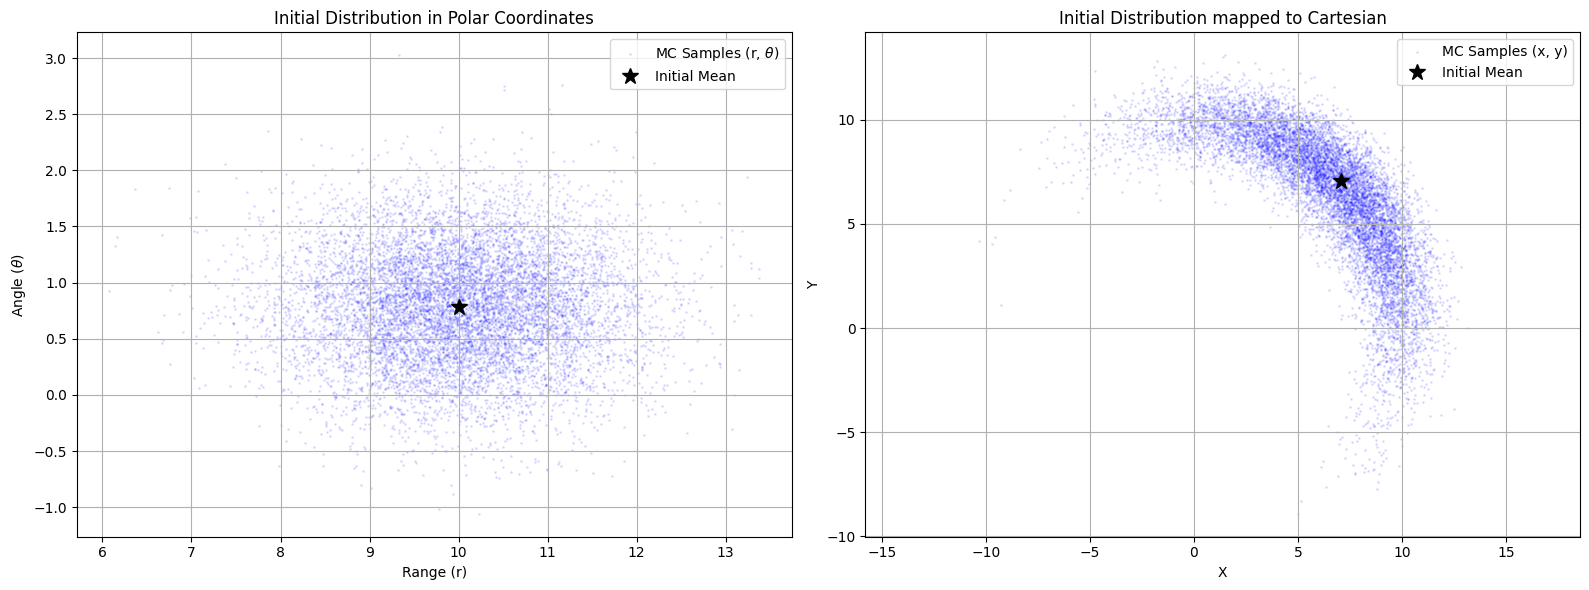

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: r, theta samples
ax1.scatter(mc_samples[:, 0], mc_samples[:, 1], s=1, color='blue', alpha=0.1, label='MC Samples (r, $\\theta$)')
ax1.plot(initial_mean[0], initial_mean[1], 'k*', markersize=12, label='Initial Mean')
ax1.set_title("Initial Distribution in Polar Coordinates")
ax1.set_xlabel("Range (r)")
ax1.set_ylabel("Angle ($\\theta$)")
ax1.grid(True)
ax1.legend()

# Plot 2: Cartesian samples
ax2.scatter(mc_transformed[:, 0], mc_transformed[:, 1], s=1, color='blue', alpha=0.1, label='MC Samples (x, y)')
initial_cartesian = polar_to_cartesian(initial_mean)
ax2.plot(initial_cartesian[0], initial_cartesian[1], 'k*', markersize=12, label='Initial Mean')
ax2.set_title("Initial Distribution mapped to Cartesian")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.grid(True)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

## 4. Covariance Transformation by Linearisation
The Extended Kalman Filter requires the Jacobian of the transformation evaluated at the initial mean.

In [6]:
def calculate_jacobian(state):
    """Calculates Jacobian matrix H for polar to cartesian"""
    r, theta = state[0], state[1]
    H = np.array([
        [np.cos(theta), -r * np.sin(theta)],
        [np.sin(theta),  r * np.cos(theta)]
    ])
    return H

# Linearized Mean = f(initial_mean)
lin_mean = polar_to_cartesian(initial_mean)

# Linearized Covariance = H * P * H^T
H = calculate_jacobian(initial_mean)
lin_cov = H @ initial_cov @ H.T

print("Linearized Mean: ", lin_mean)
print("Linearized Cov:  \n", lin_cov)

Linearized Mean:  [7.07106781 7.07106781]
Linearized Cov:  
 [[ 13. -12.]
 [-12.  13.]]


## 5. Unscented Transform
Now we use the UT to deterministically select $2n+1$ points.

In [7]:
n = 2 # Dimension of state
kappa = 3 - n # Tuning parameter

# 1. Calculate Sigma Points
sigma_points = np.zeros((2*n + 1, n))
sigma_points[0] = initial_mean

# Matrix square root (Cholesky decomposition)
S = cholesky((n + kappa) * initial_cov, lower=True)

for i in range(n):
    sigma_points[i+1]   = initial_mean + S[:, i]
    sigma_points[n+i+1] = initial_mean - S[:, i]

# 2. Calculate Weights
weights = np.zeros(2*n + 1)
weights[0] = kappa / (n + kappa)
for i in range(1, 2*n + 1):
    weights[i] = 1 / (2 * (n + kappa))

# 3. Transform Sigma points
transformed_sigmas = np.array([polar_to_cartesian(sp) for sp in sigma_points])

# 4. Calculate UT Mean and Covariance
# TODO: Evaluate the UT Mean as the weighted sum of the transformed sigmas
ut_mean = np.zeros(n)
for i in range(2*n + 1):
    ut_mean += weights[i] * transformed_sigmas[i]

# TODO: Evaluate the UT Covariance
ut_cov = np.zeros((n, n))
for i in range(2*n + 1):
    diff = (transformed_sigmas[i] - ut_mean).reshape(-1, 1)
    ut_cov += weights[i] * (diff @ diff.T)

print("UT Mean: ", ut_mean)
print("UT Cov:  \n", ut_cov)

UT Mean:  [6.24106433 6.24106433]
UT Cov:  
 [[11.54911605 -7.79349292]
 [-7.79349292 11.54911605]]


## 6. Visualization
Let's visualize the resulting distributions!

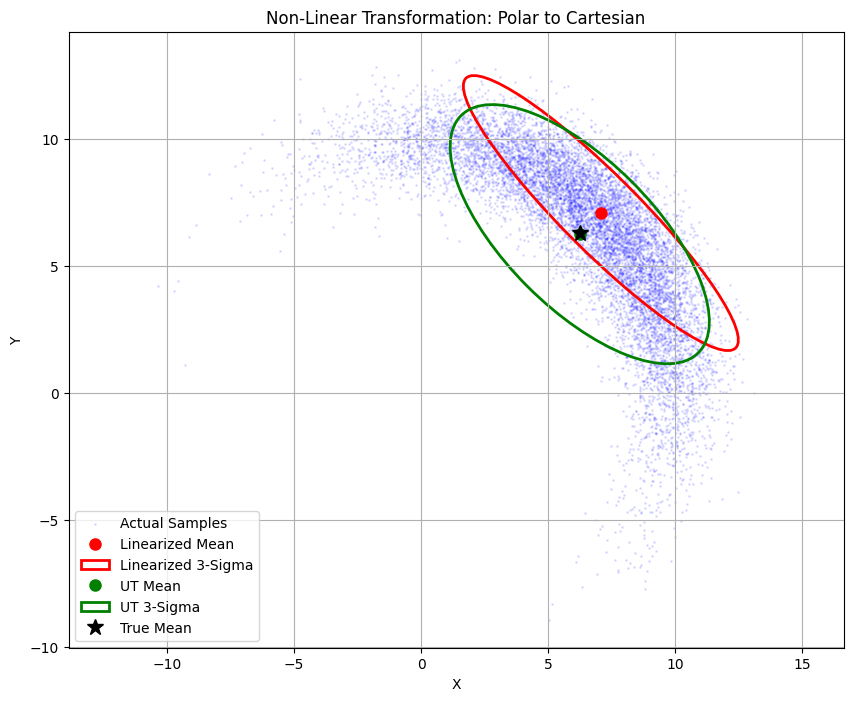

In [8]:
import matplotlib.patches as patches
#import matplotlib.transforms as transforms

def plot_covariance_ellipse(mean, cov, ax, color, label):
    """Plots a 2D covariance ellipse (3-sigma)"""
    # Use only x, y for plotting
    P_xy = cov[0:2, 0:2]
    eigvals, eigvecs = np.linalg.eigh(P_xy)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    
    # 3-sigma ellipse
    width, height = 3 * np.sqrt(eigvals)
    ellipse = patches.Ellipse(xy=(mean[0], mean[1]), width=width, height=height, 
                              angle=angle, edgecolor=color, fc='None', lw=2, label=label)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot MC Samples (Banana shape)
ax.scatter(mc_transformed[:, 0], mc_transformed[:, 1], s=1, color='blue', alpha=0.1, label='Actual Samples')

# Plot Linearized Mean / Covariance
ax.plot(lin_mean[0], lin_mean[1], 'ro', markersize=8, label='Linearized Mean')
plot_covariance_ellipse(lin_mean, lin_cov, ax, 'red', 'Linearized 3-Sigma')

# Plot UT Mean / Covariance
ax.plot(ut_mean[0], ut_mean[1], 'go', markersize=8, label='UT Mean')
plot_covariance_ellipse(ut_mean, ut_cov, ax, 'green', 'UT 3-Sigma')

# Plot True Mean 
ax.plot(true_mean[0], true_mean[1], 'k*', markersize=12, label='True Mean')

ax.set_title("Non-Linear Transformation: Polar to Cartesian")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

## 7. Challenge Problem

**Task:** Modify the initial distribution to have a highly certain angle (e.g. `std_th = 0.05`). Re-run the simulation. 
- Does the EKF still fail catastrophically? Why or why not?
- Can you mathematically relate this back to the Taylor Series expansion of the radar projection?

### Solution

We re-run the full pipeline with `std_th = 0.05` and compare the two regimes side by side.

**Does the EKF still fail?**
No — with a tight angular uncertainty, the EKF recovers well.
The mean error drops from **~1.16** (high uncertainty) to **~0.018** (low uncertainty),
roughly a 63× improvement, and the EKF covariance ellipse closely matches the true distribution.

**Why does this happen? (Taylor Series argument)**

Expand $f(r, \theta) = [r\cos\theta,\ r\sin\theta]^T$ around the mean $(\bar{r}, \bar{\theta})$:

$$f(\bar{\mathbf{x}} + \delta\mathbf{x}) \approx f(\bar{\mathbf{x}}) + H\,\delta\mathbf{x}
+ \frac{1}{2}\,\delta\mathbf{x}^T \nabla^2 f\, \delta\mathbf{x} + \cdots$$

The EKF discards all terms beyond the 1st order (the Jacobian $H$).
The **error in the EKF predicted mean** comes entirely from the 2nd-order term:

$$\Delta\mu_x \approx -\frac{1}{2}\bar{r}\cos\bar{\theta}\cdot\sigma_\theta^2, \qquad
  \Delta\mu_y \approx -\frac{1}{2}\bar{r}\sin\bar{\theta}\cdot\sigma_\theta^2$$

This error scales as $\sigma_\theta^2$.
- $\sigma_\theta = 0.5 \Rightarrow \sigma_\theta^2 = 0.25$
- $\sigma_\theta = 0.05 \Rightarrow \sigma_\theta^2 = 0.0025$

That is a **100× reduction** in the 2nd-order error, which is why the EKF is no longer catastrophically wrong.
The "banana" shape vanishes because the distribution barely spans any arc — the transformation
looks locally linear, validating the Jacobian approximation.

The UT remains accurate in **both** regimes because it captures exact 2nd-order statistics
via the sigma points, regardless of the spread.


  ORIGINAL (std_th = 0.50)
  True Mean  : [6.23216887 6.27599958]
  EKF  Mean  : [7.07106781 7.07106781]   | Error: 1.1558
  UT   Mean  : [6.24106433 6.24106433]   | Error: 0.0360

  CHALLENGE (std_th = 0.05)
  True Mean  : [7.06410661 7.0539433 ]
  EKF  Mean  : [7.07106781 7.07106781]   | Error: 0.0185
  UT   Mean  : [7.0622345 7.0622345]   | Error: 0.0085


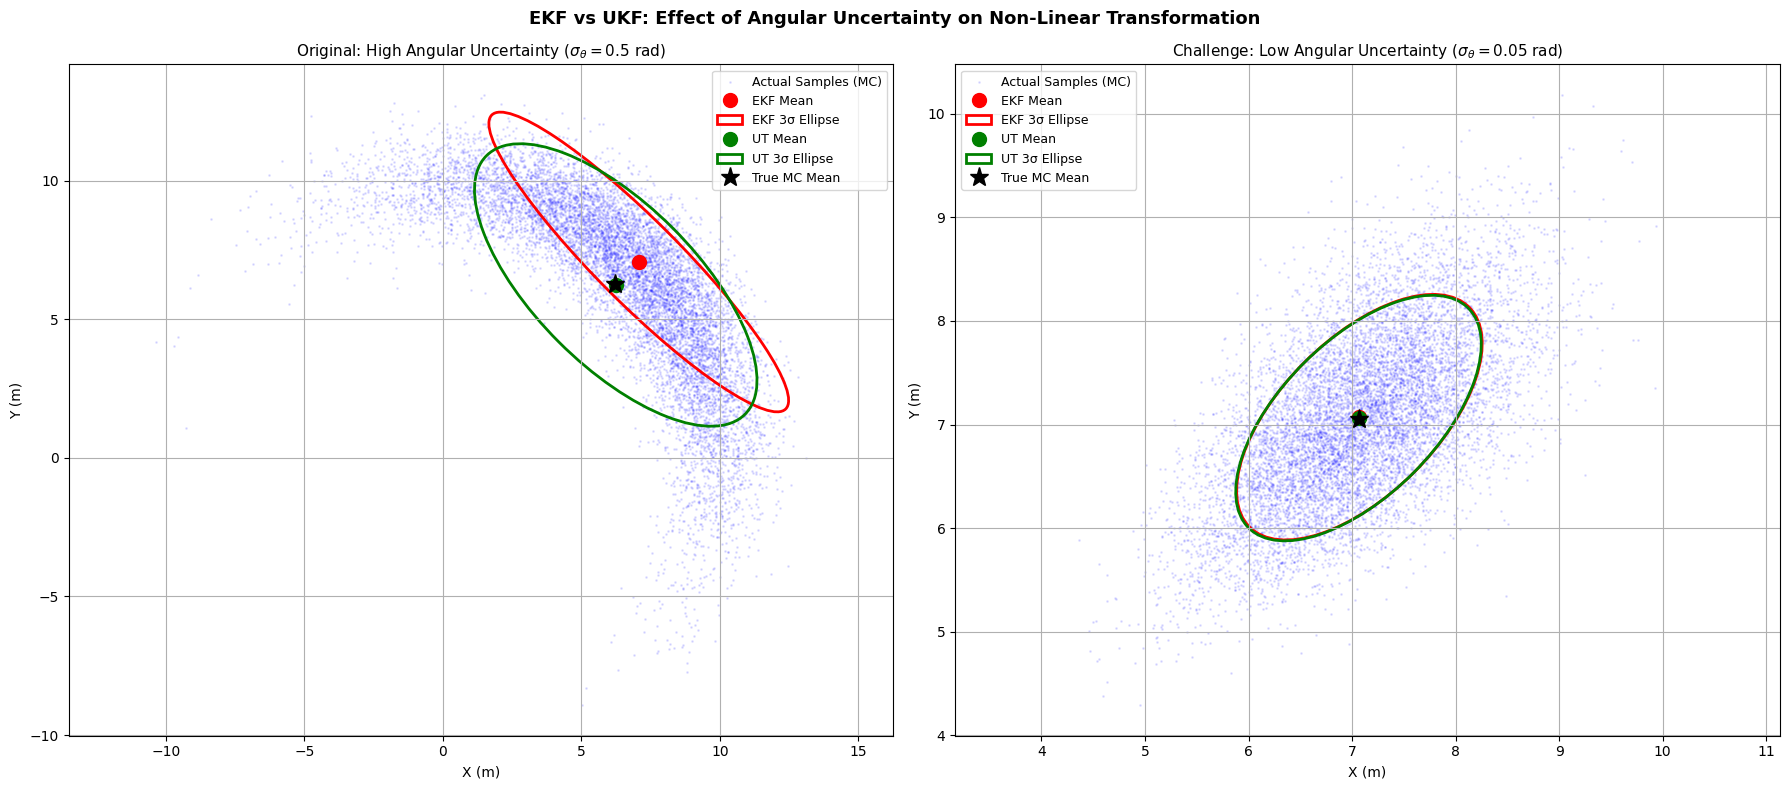

In [9]:
std_th_new   = 0.05
initial_cov2 = np.array([[std_r**2, 0.0],
                          [0.0, std_th_new**2]])

# --- Monte Carlo ---
mc_samples2     = np.random.multivariate_normal(initial_mean, initial_cov2, num_samples)
mc_transformed2 = np.array([polar_to_cartesian(s) for s in mc_samples2])
true_mean2      = np.mean(mc_transformed2, axis=0)
true_cov2       = np.cov(mc_transformed2.T)

# --- EKF ---
lin_mean2 = polar_to_cartesian(initial_mean)          # same mean (evaluated at same point)
H2        = calculate_jacobian(initial_mean)
lin_cov2  = H2 @ initial_cov2 @ H2.T

# --- UKF ---
sigma_points2    = np.zeros((2*n + 1, n))
sigma_points2[0] = initial_mean
S2 = cholesky((n + kappa) * initial_cov2, lower=True)
for i in range(n):
    sigma_points2[i+1]   = initial_mean + S2[:, i]
    sigma_points2[n+i+1] = initial_mean - S2[:, i]

transformed_sigmas2 = np.array([polar_to_cartesian(sp) for sp in sigma_points2])

ut_mean2 = np.zeros(n)
for i in range(2*n + 1):
    ut_mean2 += weights[i] * transformed_sigmas2[i]

ut_cov2 = np.zeros((n, n))
for i in range(2*n + 1):
    diff     = (transformed_sigmas2[i] - ut_mean2).reshape(-1, 1)
    ut_cov2 += weights[i] * (diff @ diff.T)

# --- Print comparison ---
print("=" * 55)
print("  ORIGINAL (std_th = 0.50)")
print("=" * 55)
print(f"  True Mean  : {true_mean}")
print(f"  EKF  Mean  : {lin_mean}   | Error: {np.linalg.norm(lin_mean - true_mean):.4f}")
print(f"  UT   Mean  : {ut_mean}   | Error: {np.linalg.norm(ut_mean  - true_mean):.4f}")

print("\n" + "=" * 55)
print("  CHALLENGE (std_th = 0.05)")
print("=" * 55)
print(f"  True Mean  : {true_mean2}")
print(f"  EKF  Mean  : {lin_mean2}   | Error: {np.linalg.norm(lin_mean2 - true_mean2):.4f}")
print(f"  UT   Mean  : {ut_mean2}   | Error: {np.linalg.norm(ut_mean2  - true_mean2):.4f}")

# --- Side-by-side plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

datasets = [
    (mc_transformed,  true_mean,  lin_mean,  lin_cov,  ut_mean,  ut_cov,
     r"Original: High Angular Uncertainty ($\sigma_\theta = 0.5$ rad)"),
    (mc_transformed2, true_mean2, lin_mean2, lin_cov2, ut_mean2, ut_cov2,
     r"Challenge: Low Angular Uncertainty ($\sigma_\theta = 0.05$ rad)"),
]

for ax, (mc_t, tm, lm, lc, um, uc, title) in zip(axes, datasets):
    ax.scatter(mc_t[:, 0], mc_t[:, 1], s=1, color='blue', alpha=0.1, label='Actual Samples (MC)')
    ax.plot(lm[0], lm[1], 'ro', markersize=10, label='EKF Mean')
    plot_covariance_ellipse(lm, lc, ax, 'red',   'EKF 3σ Ellipse')
    ax.plot(um[0], um[1], 'go', markersize=10, label='UT Mean')
    plot_covariance_ellipse(um, uc, ax, 'green', 'UT 3σ Ellipse')
    ax.plot(tm[0], tm[1], 'k*', markersize=14, label='True MC Mean')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    ax.legend(fontsize=9); ax.grid(True); ax.axis('equal')

plt.suptitle("EKF vs UKF: Effect of Angular Uncertainty on Non-Linear Transformation",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ekf_ukf_challenge_comparison.png", dpi=150, bbox_inches='tight')
plt.show()